# scRNA-seq Analysis: Endometrial Cancer (GSE203612)

Three human uterine corpus endometrial carcinoma (UCEC) tumors (GSM6177620-22),
profiled by inDrop, from Barkley et al. 2022.

Run the pipeline first (from the repository root):
1. `scripts/preprocess.py` : download, QC, per-library Scrublet, normalization
2. `scripts/clustering.py` : PCA, Harmony across patients, Leiden, UMAP
3. `scripts/annotate.py` : marker-panel annotation; CellTypist cross-check on immune clusters
4. `scripts/machine_learning.py` : classifier (random split and leave-one-patient-out) and gene attributions
5. `scripts/export_signature_matrix.py`, `scripts/cell_communication.py` : optional downstream steps

This notebook only inspects the saved outputs.

In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.figdir = "../results/figures"
RESULTS = "../results"

## Load the annotated data

`annotate.py` writes `annotated_data.h5ad`; `processed_data.h5ad` (clustering output) has no `cell_type`.

In [2]:
adata = sc.read("../data/annotated_data.h5ad")
assert "leiden_clusters" in adata.obs, "Run scripts/clustering.py first"
assert "cell_type" in adata.obs, "Run scripts/annotate.py first"
adata

AnnData object with n_obs × n_vars = 8000 × 2928
    obs: 'sample_id', 'library_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'scrublet_threshold', 'leiden_clusters', 'library_key', 'marker_gene_label', 't_nk_subtype_lean', 'stromal_subtype_lean', 'predicted_labels', 'majority_voting', 'conf_score', 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cell_type_colors', 'celltypist_model_info', 'clustering_params', 'hvg', 'leiden_clusters', 'leiden_clusters_colors', 'library_key_colors', 'log1p', 'neighbors', 'pca', 'preprocess_params', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Run parameters

In [3]:
adata.uns.get("clustering_params", "no clustering_params recorded")

{'embedding': 'X_pca_harmony',
 'harmony_batch_key': 'sample_id',
 'harmonypy_version': '2.0.2',
 'leiden_flavor': 'igraph',
 'n_neighbors': 20,
 'n_pcs': 20,
 'n_pcs_computed': 50,
 'pca_input': 'log-normalized HVG matrix, not scaled',
 'python_version': '3.11.16',
 'random_state': 0,
 'resolution': 1.0,
 'scanpy_version': '1.11.5',
 'stability_mean_ari': 0.74425544840323,
 'stability_min_ari': 0.7301973093280826,
 'stability_subsample_fraction': 0.9,
 'timestamp_utc': '2026-10-01T07:01:07.593362+00:00'}

## PCA variance explained

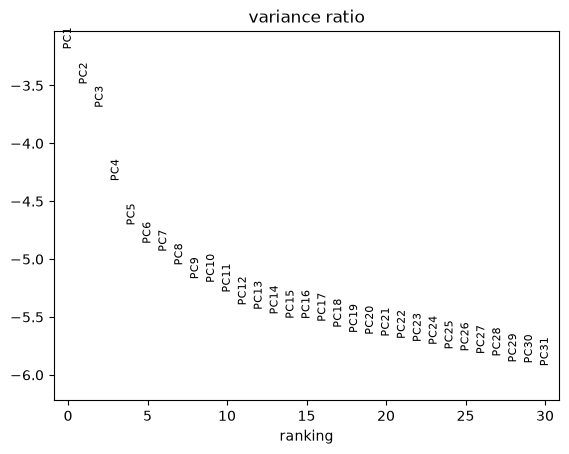

In [4]:
sc.pl.pca_variance_ratio(adata, log=True)

## UMAP: Leiden clusters vs. marker-panel cell types

`cell_type` is the marker-panel label (primary annotation). Clusters where no
type was clearly ahead are labeled `Ambiguous`.

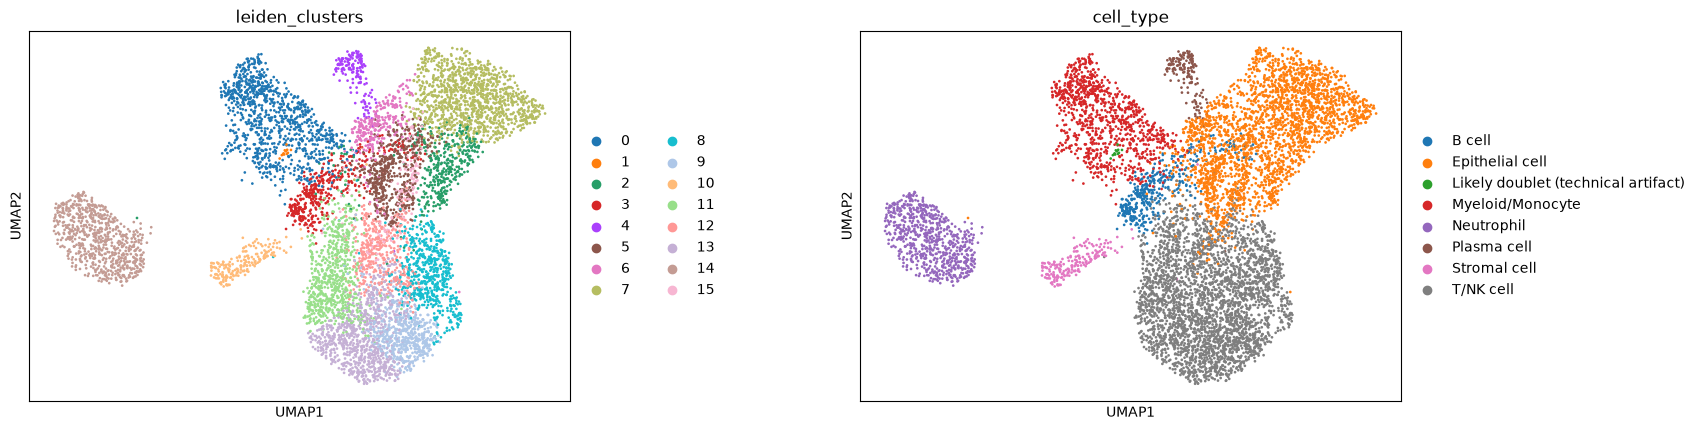

cell_type
T/NK cell                              3073
Epithelial cell                        2514
Myeloid/Monocyte                        960
Neutrophil                              700
B cell                                  395
Stromal cell                            192
Plasma cell                             154
Likely doublet (technical artifact)      12
Name: count, dtype: int64

In [5]:
sc.pl.umap(adata, color=["leiden_clusters", "cell_type"], wspace=0.4)
adata.obs["cell_type"].value_counts()

## Integration checks: patients and libraries

Harmony corrects between patients only. Clusters should mix patients; a
cluster dominated by one *library* of a multi-library patient would point to
an uncorrected technical effect.

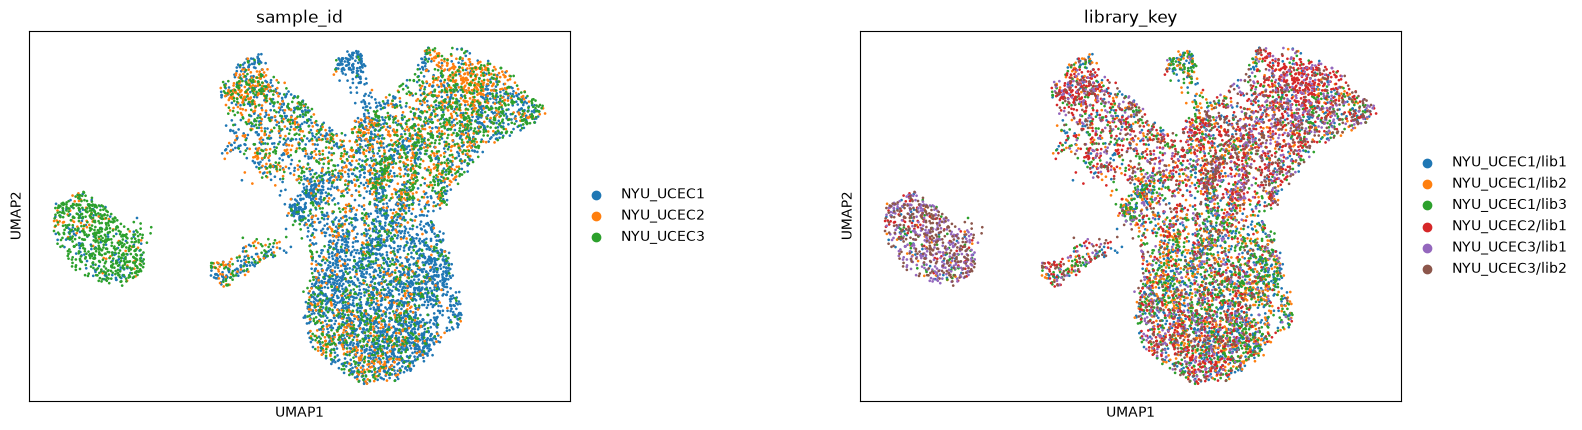

,NYU_UCEC1/lib1,NYU_UCEC1/lib2,NYU_UCEC1/lib3,NYU_UCEC2/lib1,NYU_UCEC3/lib1,NYU_UCEC3/lib2
leiden_clusters,,,,,,
0,0.13,0.12,0.16,0.31,0.14,0.14
1,0.42,0.00,0.00,0.58,0.00,0.00
2,0.10,0.10,0.14,0.29,0.15,0.22
3,0.24,0.21,0.29,0.11,0.11,0.05
4,0.27,0.28,0.38,0.03,0.02,0.02
5,0.16,0.15,0.15,0.22,0.15,0.18
6,0.13,0.18,0.15,0.27,0.10,0.18
7,0.11,0.10,0.12,0.34,0.18,0.15
8,0.29,0.23,0.31,0.06,0.05,0.05


In [6]:
sc.pl.umap(adata, color=["sample_id", "library_key"], wspace=0.4)
pd.read_csv(f"{RESULTS}/cluster_by_library_proportions.csv", index_col=0).round(2)

## Doublet scores (Scrublet, per library)

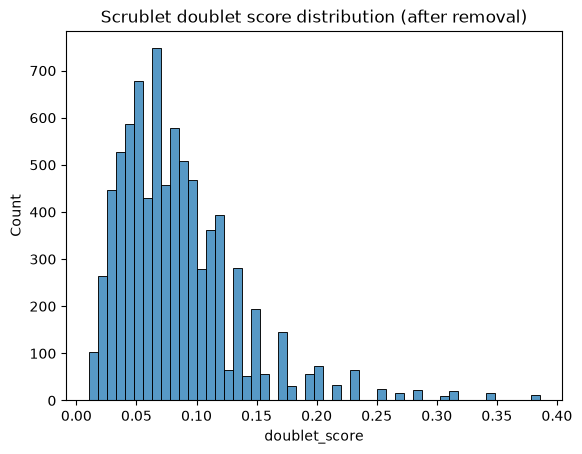

In [7]:
if "doublet_score" in adata.obs:
    sns.histplot(adata.obs["doublet_score"], bins=50)
    plt.title("Scrublet doublet score distribution (after removal)")
    plt.show()

## Annotation evidence

Per-cluster marker scores and margins, per-cell concordance with the cluster
label, and the CellTypist cross-check on immune clusters (CellTypist run on
all genes, majority voting over Leiden clusters).

In [8]:
display(pd.read_csv(f"{RESULTS}/marker_annotation_confidence.csv"))
display(pd.read_csv(f"{RESULTS}/cluster_annotation_concordance.csv"))
display(pd.read_csv(f"{RESULTS}/annotation_cross_check_immune_only.csv"))

,leiden_cluster,assigned_label,top_type,top_score,second_type,second_score,margin,top_type_pct_cells_expressing_markers
0,0,Myeloid/Monocyte,Myeloid/Monocyte,3.521908,Dendritic cell,1.522854,1.999054,0.622
1,1,Dendritic cell,Dendritic cell,1.671248,Epithelial cell,1.515805,0.155443,0.278
2,2,Epithelial cell,Epithelial cell,0.457620,Myeloid/Monocyte,-0.203455,0.661075,0.081
3,3,B cell,B cell,2.890486,Dendritic cell,0.712068,2.178417,0.245
4,4,Plasma cell,Plasma cell,3.779659,B cell,1.649790,2.129869,0.786
5,5,Epithelial cell,Epithelial cell,0.150860,B cell,-0.229290,0.380150,0.052
6,6,Epithelial cell,Epithelial cell,0.302041,Stromal cell,-0.271066,0.573106,0.061
7,7,Epithelial cell,Epithelial cell,3.068493,Plasma cell,0.048947,3.019546,0.369
8,8,T/NK cell,T/NK cell,1.742618,Stromal cell,-0.241871,1.984489,0.305
9,9,T/NK cell,T/NK cell,2.130270,Stromal cell,-0.230915,2.361185,0.346


,leiden_cluster,concordant,ambiguous_cell,discordant_other
0,0,0.710417,0.113542,0.176042
1,1,0.583333,0.166667,0.250000
2,2,0.215223,0.511811,0.272966
3,3,0.453165,0.311392,0.235443
4,4,0.883117,0.045455,0.071429
5,5,0.151803,0.542694,0.305503
6,6,0.204225,0.531690,0.264085
7,7,0.663837,0.179117,0.157046
8,8,0.622222,0.247863,0.129915
9,9,0.670175,0.198246,0.131579


,leiden_clusters,majority_voting,marker_gene_label,compatible
0,0,Macrophages,Myeloid/Monocyte,True
1,1,Epithelial cells,Dendritic cell,False
2,3,Memory B cells,B cell,True
3,4,Plasma cells,Plasma cell,True
4,8,Tem/Trm cytotoxic T cells,T/NK cell,True
5,9,Tem/Trm cytotoxic T cells,T/NK cell,True
6,11,Regulatory T cells,T/NK cell,True
7,12,Tcm/Naive helper T cells,T/NK cell,True
8,13,Trm cytotoxic T cells,T/NK cell,True
9,14,Classical monocytes,Neutrophil,False


## Cross-patient label transfer

Labels are the marker-panel cell types (Ambiguous/Unknown/doublet excluded).
The random cell-level split is optimistic, since cells from the same clusters
fall on both sides. The leave-one-patient-out results show how consistently
annotations transfer to an unseen patient, not independent validation, since
every patient contributed to the labels and features.

In [9]:
with open("../models/classification_report.txt") as f:
    print(f.read())

Random cell-level split (optimistic: cells from the same clusters in train and test)

                  precision    recall  f1-score   support

          B cell       0.91      0.91      0.91        79
 Epithelial cell       0.97      0.97      0.97       503
Myeloid/Monocyte       0.97      0.99      0.98       192
      Neutrophil       0.99      0.99      0.99       140
     Plasma cell       0.91      0.94      0.92        31
    Stromal cell       0.97      0.97      0.97        38
       T/NK cell       0.98      0.98      0.98       615

        accuracy                           0.97      1598
       macro avg       0.96      0.96      0.96      1598
    weighted avg       0.97      0.97      0.97      1598


Leave-one-patient-out evaluation

held_out_patient  n_train  n_test  accuracy  macro_f1 classes_missing_from_training
       NYU_UCEC1     3878    4110  0.901703  0.792494                            []
       NYU_UCEC2     6376    1612  0.951613  0.777870                 

## Data-driven marker candidates

Genes ranked by their signed attribution in the trained classifier, keeping only
genes **up-regulated** in the cell type (DE log2FC > 0, adjusted p < 0.05).

Why the filter: attributions are measured against the average cell, which is
mostly immune here. A gene can therefore rank highly because it is *absent*
from a cell type. For example, CXCR4 and HLA-DRA get high attributions for
epithelial cells because epithelial cells lack them. That is evidence the model
uses, but not a marker. The unfiltered ranking is in
`results/data_driven_marker_discovery.csv`.

In [10]:
discovery = pd.read_csv(f"{RESULTS}/data_driven_marker_discovery.csv")
up = discovery[(discovery["de_log2fc"] > 0) & (discovery["de_pval_adj"] < 0.05)]
(up.sort_values(["cell_type", "rank"])
   .groupby("cell_type").head(5)
   [["cell_type", "rank", "gene", "mean_ig_attribution", "in_curated_panel",
     "de_log2fc", "de_pval_adj", "consistent_across_patients"]])

,cell_type,rank,gene,mean_ig_attribution,in_curated_panel,de_log2fc,de_pval_adj,consistent_across_patients
0,B cell,1,HLA-DRA,2.780074,False,5.237102,1.120244e-163,True
1,B cell,2,HLA-DPA1,0.448141,False,2.539610,3.557883e-28,True
3,B cell,4,CD79A,0.170427,True,4.777849,6.164147e-26,False
5,B cell,6,HLA-DQA1,0.156746,False,2.039366,6.425647e-11,True
7,B cell,8,MS4A1,0.103791,True,6.284572,8.122588e-17,False
15,Epithelial cell,1,WFDC2,0.669612,False,4.820498,5.840880e-301,True
17,Epithelial cell,3,SAT1,0.326004,False,0.382935,7.158952e-07,True
19,Epithelial cell,5,SOX4,0.251997,False,3.519086,3.139947e-172,True
20,Epithelial cell,6,MARCKSL1,0.211880,False,3.089653,1.663950e-155,True
21,Epithelial cell,7,TUBA1B,0.181793,False,1.264785,4.066535e-41,True
